In [188]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEndpointEmbeddings

In [189]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["HUGGINGFACEHUB_API_TOKEN"] = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [190]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    
]
docs= [WebBaseLoader(url).load() for url in urls]
docs_list= [item for sublist in docs for item in sublist]
chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs_list)
embeddings=HuggingFaceEndpointEmbeddings(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",task="feature-extraction")
store=FAISS.from_documents(chunks,embeddings)
retriever=store.as_retriever()
retriever


VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEndpointEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7f8b49ca0c80>, search_kwargs={})

In [191]:
from pydantic import BaseModel,Field
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
class Analysis_State(BaseModel):
    binary_choice: Literal["vector_store","web_search"] =Field(
        description="field will be redirect to be vector_store or web_search"
    )

llm=ChatGroq(model="llama-3.3-70b-versatile")
llm_structed=llm.with_structured_output(Analysis_State)

system_prompt_analysis="""You are an expert query analyzer and router. Your job is to determine if a user's question should be answered using a specialized 'vector_store' or a general 'web_search'.

### CONTEXT OF VECTOR STORE:
The vector store contains high-level technical documentation regarding:
1. LLM-powered Autonomous Agents (Planning, Memory, Tool Use).
2. Prompt Engineering techniques (Chain of Thought, ReAct, Reflexion).
3. Adversarial Attacks on LLMs (Prompt Injection, Jailbreaking, Robustness).

### ROUTING LOGIC:
- ROUTE to 'vector_store' if the question is about Agent architectures, specific memory types (Short-term/Long-term/SMC), prompt engineering strategies, or LLM security/attacks mentioned in Lilian Weng's research.
- ROUTE to 'web_search' if the question is about current news, unrelated technologies, coding help not specific to agents, or general knowledge outside the technical topics listed above.

### OUTPUT FORMAT:
Return a JSON object with a single key 'datasource'. No preamble or explanation.
Example: {{"datasource": "vector_store"}}"""

llm_prompt= ChatPromptTemplate.from_messages(
    [
        ("system",system_prompt_analysis)
        ,("human","{question}")
    ]
)
analysis_chain=llm_prompt | llm_structed
x=analysis_chain.invoke({"question":"what is the winner of world cup 2022?"})
print(type(x.binary_choice))

<class 'str'>


In [192]:
class Grade_State(BaseModel):
    binary_score:str=Field(description="question will be grading it i relevant or not " \
    "answer will be yes or no ")

from langchain_core.output_parsers import JsonOutputParser

# 1. الموديل بوضع الـ JSON Mode الصريح (بدل with_structured_output)
llm_json = llm.bind(response_format={"type": "json_object"})

# 2. برومبت واضح مع تعليمات الـ JSON
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a grader assessing relevance of a retrieved document to a user question. \n"
               "Return ONLY a JSON object with a single key 'binary_score' which is either 'yes' or 'no'."),
    ("human", "Retrieved document: \n\n {document} \n\n User question: {question}")
])

# 3. الـ Chain الجديدة بتستخدم JsonOutputParser
# الـ Parser ده "شاطر" بيعرف يلقط الـ JSON حتى لو الموديل خرف
grade_chain = grade_prompt | llm_json | JsonOutputParser()

question="agent memory"
results=retriever.invoke(question)
results=results[1].page_content

print(grade_chain.invoke({"question":question,"document":results}))



{'binary_score': 'yes'}


In [193]:
from langsmith import Client
client = Client()
answer_prompt = client.pull_prompt("rlm/rag-prompt")

generate_answer_chain=answer_prompt | llm | StrOutputParser()

generation=generate_answer_chain.invoke({"question":question,"context":retriever.invoke(question)})
print(generation)

In a LLM-powered autonomous agent system, there are two types of memory: short-term memory and long-term memory. Short-term memory utilizes in-context learning, while long-term memory provides the capability to retain and recall information over extended periods, often by leveraging an external vector store and fast retrieval. Long-term memory can be implemented as a memory stream, an external database that records the agent's experience in natural language.


In [194]:
# from langchain_core.output_parsers import JsonOutputParser
# class hallucination_State(BaseModel):
#     score:str=Field(description="check hallucination of the retrieved documents")

# llm_hallucination=llm.with_structured_output(hallucination_State)

# system_hallucination = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
#      Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

# hallucination_prompt = ChatPromptTemplate.from_messages([
#     ("system", system_hallucination),
#     ("human", "Set of documents: \n\n {documents} \n\n LLM generation: {generation}")
# ])


# hallucination_chain=hallucination_prompt | llm_hallucination 
# docs = retriever.invoke(question)

# # ب. حولهم لنص (String) - ده السر اللي هيمنع الـ Error 400
# docs_as_string = "\n\n".join([d.page_content for d in docs])

# # ج. نادى الـ Chain وأنت مطمن
# result = hallucination_chain.invoke({
#     "documents": docs_as_string, 
#     "generation": generation
# })

# print(result.binary_score)
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field

# 1. الـ Class بتاعتك زي ما هي
class Hallucination_State(BaseModel):
    binary_score: str = Field(description="Answer is grounded in facts, 'yes' or 'no'")

# 2. تعريف الـ Parser وربطه بالـ Class
# دي الخطوة السحرية: الـ Parser دلوقت "عارف" شكل الـ Class
parser = JsonOutputParser(pydantic_object=Hallucination_State)

# 3. الموديل بوضع الـ JSON Mode (عشان نهرب من Error 400)
llm_json = llm.bind(response_format={"type": "json_object"})

# 4. تعديل الـ Prompt عشان يلتزم بالـ Schema
system_hallucination = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved documents. 

Grade 'yes' if the generation is supported by the documents, otherwise grade 'no'.

{format_instructions}"""

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", system_hallucination),
    ("human", "Set of documents: \n\n {documents} \n\n LLM generation: {generation}")
]).partial(format_instructions=parser.get_format_instructions()) # بيبعت للموديل مواصفات الـ Class

# 5. الـ Chain
hallucination_chain = hallucination_prompt | llm_json | parser

# 6. التنفيذ
docs = retriever.invoke(question)
docs_txt = "\n\n".join([d.page_content for d in docs])

result = hallucination_chain.invoke({
    "documents": docs_txt, 
    "generation": generation
})

# دلوقت الـ result هو Object من Hallucination_State
# تقدر تتأكد وتعمل كدة:
print(f"Type: {type(result)}") 
print(f"Score: {result['binary_score']}") # الـ JsonOutputParser بيرجع dictionary بس ملتزم بالـ Schema

Type: <class 'dict'>
Score: yes


In [195]:
#relevant answer

# 1. تعريف الـ Class
class Answer_State(BaseModel):
    binary_score: str = Field(description="Does the answer address the question? 'yes' or 'no'")

answer_llm_structured = llm.with_structured_output(Answer_State)

system_answer = """You are a grader assessing whether an answer addresses / resolves a user question. 
Give a binary score 'yes' or 'no'. 
- 'yes' means the answer actually answers the question.
- 'no' means the answer is irrelevant or misses the point."""

answer_prompt = ChatPromptTemplate.from_messages([
    ("system", system_answer),
    ("human", "User question: \n\n {question} \n\n LLM generation: {generation}")
])


answer_chain = answer_prompt | answer_llm_structured




result = answer_chain.invoke({"question": question, "generation": generation})


print(result.binary_score)

yes


In [196]:
from langsmith import Client

client = Client()
re_write_prompt = client.pull_prompt("efriis/self-rag-question-rewriter")
rewriting=re_write_prompt | llm | StrOutputParser()
rewriting.invoke({"question":"agent memory"})



'To better understand the underlying semantic intent of the input question "agent memory", I\'ll try to reason about what it could be related to. \n\nHere are a few possibilities:\n1. **Artificial Intelligence**: The term "agent" is often used in AI to refer to autonomous entities that can perceive their environment and take actions. In this context, "agent memory" might refer to the ability of an AI agent to store and recall information.\n2. **Computer Science**: In computer science, an "agent" can refer to a software program that performs tasks on behalf of a user. "Agent memory" could be related to the memory management of such agents.\n3. **Cognitive Science**: In cognitive science, "agent" can refer to a human or non-human entity that interacts with its environment. "Agent memory" might be related to the cognitive processes involved in memory formation and retrieval.\n\nWith these possibilities in mind, here are a few improved question formulations:\n\n* What is the role of memory

In [197]:
from langchain_community.tools.tavily_search import TavilySearchResults
web_search= TavilySearchResults(k=2)

In [198]:
from typing import TypedDict, Annotated, List
import operator

class State(TypedDict):
    question: str
    answer: str
    web_search_result: str
    documents: Annotated[List[str], operator.add]
    generation_attempts: int      # ← عدد محاولات التوليد
    rewrite_attempts: int          # ← عدد محاولات إعادة الكتابة
    

In [ ]:
#nodes
def query_analysis(state:State) -> State:
    brunch=analysis_chain.invoke({"question": state["question"]})
    return brunch.binary_choice

def retrieve_data(state:State) -> State:
    results=retriever.invoke(state["question"])
    return {
        "question" : state["question"],
        "documents":results
    }

def relevant_grade_documents(state) :
  
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = grade_chain.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score['binary_score']
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}

def generate_answer(state: State):
    print("---GENERATE ANSWER---")
    question = state["question"]
    documents = state["documents"]
    attempts = state.get("generation_attempts", 0)
    
    generation = generate_answer_chain.invoke({"context": documents, "question": question})

    return {
        "question": question,
        "documents": documents,
        "answer": generation,
        "generation_attempts": attempts + 1  # ← زوّد العداد
    }
def hallucination_check(state: State):
    print("---CHECK HALLUCINATIONS---")
    
    generation_attempts = state.get("generation_attempts", 0)
    
    # لو حاول 2 مرات، stop (مش 3 عشان ميطولش)
    if generation_attempts >= 2:
        print(f"---MAX GENERATION ATTEMPTS REACHED ({generation_attempts}), PROCEEDING TO FINAL---")
        return "final"
    
    question = state["question"]
    documents = state["documents"]
    answer = state["answer"]
    
    score = hallucination_chain.invoke({
        "documents": documents,
        "generation": answer
    })
    
    grade = score["binary_score"]
    
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED---")
        return "final"
    else:
        print(f"---DECISION: HALLUCINATION DETECTED, ATTEMPT {generation_attempts + 1}/2---")
        return "generate"
    
def relevant_answer_route(state: State):
    print("---CHECK IF ANSWER ADDRESSES QUESTION---")
    question = state["question"]
    answer = state["answer"]
    rewrite_attempts = state.get("rewrite_attempts", 0)
    
    # لو حاول rewrite مرتين، stop
    if rewrite_attempts >= 2:
        print("---MAX REWRITE ATTEMPTS, ENDING---")
        return "end"
    
    score = answer_grader.invoke({"question": question, "generation": answer})
    grade = score["binary_score"]
    
    if grade == "yes":
        print("---DECISION: ANSWER ADDRESSES QUESTION---")
        return "end"
    else:
        print("---DECISION: ANSWER DOES NOT ADDRESS QUESTION---")
        return "rewrite"
    
def rewrite_query(state: State):
    print("---TRANSFORM QUERY---")
    question = state["question"]
    rewrite_attempts = state.get("rewrite_attempts", 0)
    
    # لو حاول يعيد كتابة 2 مرات، stop
    if rewrite_attempts >= 2:
        print(f"---MAX REWRITE ATTEMPTS REACHED, KEEPING ORIGINAL QUESTION---")
        return {
            "question": question,  # خليه زي ما هو
            "rewrite_attempts": rewrite_attempts + 1
        }
    
    better_question = question_rewriter.invoke({"question": question})
    print(f"---REWRITTEN QUESTION: {better_question}---")
    
    return {
        "question": better_question,
        "documents": [],  # ← reset الـ documents
        "generation_attempts": 0,  # ← reset عداد التوليد
        "rewrite_attempts": rewrite_attempts + 1
    }


def web_search_tool(state:State) -> State:
    question=state["question"]
    answer=web_search.invoke(question)
    return({
        "question":question,
        "documents":answer

    })
    




    

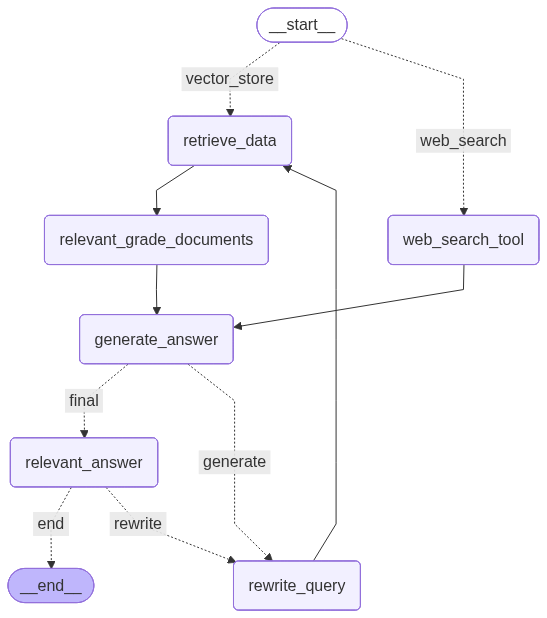

In [200]:
from langgraph.graph import StateGraph, START, END

# 1. تعريف الـ Graph
graph = StateGraph(State)

# 2. إضافة الـ Nodes (كل محطة في الرحلة)
graph.add_node("retrieve_data", retrieve_data)
graph.add_node("relevant_grade_documents", relevant_grade_documents)
graph.add_node("generate_answer", generate_answer)
graph.add_node("relevant_answer", relevant_answer) # دي Node بتغير الـ state
graph.add_node("rewrite_query", rewrite_query)
graph.add_node("web_search_tool", web_search_tool)

# 3. البداية: تحليل السؤال (Start -> Web or Vector)
graph.add_conditional_edges(
    START,
    query_analysis,
    {
        "web_search": "web_search_tool",
        "vector_store": "retrieve_data"
    }
)

# 4. المسار المباشر للتوليد
graph.add_edge("web_search_tool", "generate_answer")
graph.add_edge("retrieve_data", "relevant_grade_documents")
graph.add_edge("relevant_grade_documents", "generate_answer")

# 5. فحص الهلوسة (بعد التوليد مباشرة)
# ركز هنا: الـ Mapping لازم يروح لـ Nodes موجودة فعلاً
graph.add_conditional_edges(
    "generate_answer",
    hallucination_check,
    {
        "generate": "rewrite_query", # لو فيه هلوسة، ارجع ولد تاني
        "final": "relevant_answer"     # لو سليم، روح للـ Node اللي بتشيك على السؤال
    }
)

# 6. فحص مطابقة الإجابة للسؤال (Decision Point)
graph.add_conditional_edges(
    "relevant_answer",
    relevant_answer_route, # هنا الدالة بتقرر المسار بناءً على الـ score
    {
        "end": END,                # الإجابة ممتازة، قفل الـ Graph
        "rewrite": "rewrite_query" # الإجابة مش كافية، حسن السؤال وابحث تاني
    }
)

# 7. العودة للبحث بعد تحسين السؤال
graph.add_edge("rewrite_query", "retrieve_data")

# 8. التجهيز
app = graph.compile()
app

In [201]:
app.invoke({"question":"agent memory"})

---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GENERATE ANSWER---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED---


KeyError: 'generation'